# Figure 1 — Data: footprint, tiling & multi-band cutout

Combined data figure. **(a)** ECDFS footprint (in-distribution, tract 5063) on a Euclid VIS
mosaic, colored by tract patch. **(b)** EDF-S (first OOD sample, tract 2394). **(c)** the ten
input channels (Rubin $ugrizy$ + Euclid VIS/$YJH$) for a single matched tile.

Saves to `paper/figures/fig1_data.png`. Reuses the VIS-mosaic thumbnail cache in `paper_figures/_fig2_cache/`.

In [1]:
import numpy as np, glob, re, os
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval

def find_repo_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'data').is_dir() and (c / 'paper').is_dir():
            return c
    raise RuntimeError('repo root not found')

REPO = find_repo_root()
FIGDIR = REPO / 'paper' / 'figures'; FIGDIR.mkdir(exist_ok=True)
CACHE = REPO / 'paper_figures' / '_fig2_cache'; CACHE.mkdir(exist_ok=True)
FIELDS = {'ecdfs': REPO / 'data' / 'euclid_tiles_all',
          'edfs':  REPO / 'data' / 'edf_s_ood' / 'euclid_tiles_edfs'}
RUBIN_DIR = REPO / 'data' / 'rubin_tiles_all'
CUTOUT_TILE = 'tile_x02816_y02560_tract5063_patch_14'   # the matched tile shown in panel (c)
plt.rcParams.update({'font.size': 9, 'axes.linewidth': 0.8})
print('repo:', REPO)

repo: /home/shemmati/Work/Projects/JAISP


In [2]:
# --- build (or load) the downsampled VIS mosaic for each field ---
PAT = re.compile(r'tile_x(?P<x>\d+)_y(?P<y>\d+)(?:_tract(?P<tract>[^_]+)_patch_(?P<patch>[^_.]+))?')
BLK = 8

def block_mean(a, k):
    ny, nx = a.shape; a = a[:ny // k * k, :nx // k * k]
    return a.reshape(a.shape[0] // k, k, a.shape[1] // k, k).mean(axis=(1, 3))

def build_thumbs(tag, directory):
    cache = CACHE / f'vis_thumbs_{tag}.npz'
    if cache.exists():
        z = np.load(cache, allow_pickle=True); return z['thumbs'], z['extents'], z['patches']
    files = sorted(glob.glob(str(directory / 'tile_x*_euclid.npz')))
    thumbs, extents, patches = [], [], []
    for i, f in enumerate(files):
        d = np.load(f, allow_pickle=True)
        v = np.asarray(d['img_VIS'], np.float32); ny, nx = v.shape
        w = WCS(fits.Header.fromstring(d['wcs_VIS'].item()))
        ra_l, _ = w.all_pix2world(0, ny / 2, 0); ra_r, _ = w.all_pix2world(nx, ny / 2, 0)
        _, dec_b = w.all_pix2world(nx / 2, 0, 0); _, dec_t = w.all_pix2world(nx / 2, ny, 0)
        thumbs.append(block_mean(v, BLK).astype(np.float32))
        extents.append([float(ra_l), float(ra_r), float(dec_b), float(dec_t)])
        m = PAT.search(os.path.basename(f)); patches.append(m.group('patch') if (m and m.group('patch')) else 'edfs')
        if i % 200 == 0: print(f'{tag}: {i}/{len(files)}', flush=True)
    thumbs, extents, patches = np.array(thumbs), np.array(extents), np.array(patches)
    np.savez_compressed(cache, thumbs=thumbs, extents=extents, patches=patches)
    return thumbs, extents, patches

data = {tag: build_thumbs(tag, d) for tag, d in FIELDS.items()}
print({tag: len(v[0]) for tag, v in data.items()})

{'ecdfs': 791, 'edfs': 72}


In [3]:
# --- load the 10 bands of the matched cutout tile ---
CUTOUT_ARCSEC = 60.0   # central crop shown per band

def ccrop(a, pixscale):
    half = int(round(CUTOUT_ARCSEC / pixscale / 2)); c0, c1 = a.shape[0] // 2, a.shape[1] // 2
    return a[c0 - half:c0 + half, c1 - half:c1 + half]

rub = np.load(RUBIN_DIR / f'{CUTOUT_TILE}.npz', allow_pickle=True)
euc = np.load(FIELDS['ecdfs'] / f'{CUTOUT_TILE}_euclid.npz', allow_pickle=True)
rb = [b for b in rub['bands'].tolist()]
cut = []  # (label, group, cropped image)
for bi, b in enumerate(rb):
    cut.append((b, 'Rubin', ccrop(np.asarray(rub['img'][bi], np.float32), 0.2)))
for b in ['VIS', 'Y', 'J', 'H']:
    cut.append((b, 'Euclid', ccrop(np.asarray(euc[f'img_{b}'], np.float32), float(euc[f'pixel_scale_{b}']))))
print('cutout bands:', [c[0] for c in cut], 'shapes:', [c[2].shape for c in cut])

cutout bands: ['u', 'g', 'r', 'i', 'z', 'y', 'VIS', 'Y', 'J', 'H'] shapes: [(300, 300), (300, 300), (300, 300), (300, 300), (300, 300), (300, 300), (600, 600), (600, 600), (600, 600), (600, 600)]


saved /home/shemmati/Work/Projects/JAISP/paper/figures/fig1_data.png


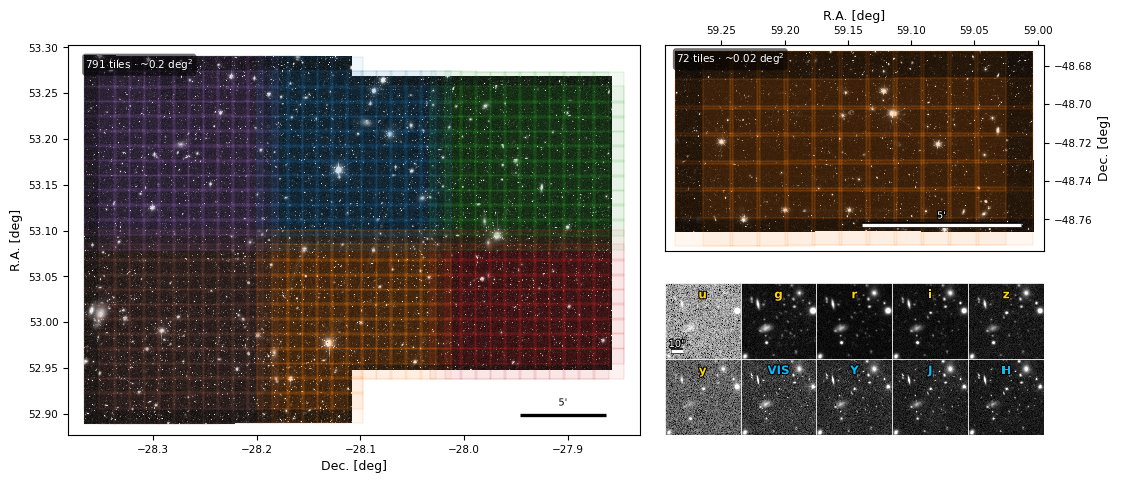

In [4]:
# ---- config you can tweak ----
FILL_ALPHA = 0.06; EDGE_ALPHA, EDGE_LW = 0.40, 0.25
MAP_STRETCH, MAP_PCT = 0.06, 99.3
CUT_STRETCH, CUT_PCT = 0.1, 99.0
CUT_BAR_ARCSEC = 10.0           # size scale drawn on the u-band cutout
import matplotlib.patheffects as pe
STROKE = [pe.withStroke(linewidth=1.6, foreground='black')]
WSTROKE = [pe.withStroke(linewidth=1.6, foreground='white')]
MARGIN_FR = 0.03

def geom(tag, rotate=False):
    """display width:height aspect of a field map; rotate -> Dec on x, RA on y."""
    _, ex, _ = data[tag]
    ra_rng = ex[:, :2].max() - ex[:, :2].min(); dec_rng = ex[:, 2:].max() - ex[:, 2:].min()
    dc = 0.5 * (ex[:, 2:].min() + ex[:, 2:].max()); cosd = np.cos(np.deg2rad(dc))
    a = ra_rng * cosd / dec_rng
    return 1.0 / a if rotate else a

def draw_map(ax, tag, color_by_patch, label, scalebar=5.0, rotate=False):
    thumbs, extents, patches = data[tag]
    norm = ImageNormalize(np.concatenate([t.ravel() for t in thumbs[::20]]),
                          interval=PercentileInterval(MAP_PCT), stretch=AsinhStretch(MAP_STRETCH))
    dc = 0.5 * (extents[:, 2:].min() + extents[:, 2:].max()); cosd = np.cos(np.deg2rad(dc))
    for t, e in zip(thumbs, extents):
        if rotate:
            ax.imshow(t.T, extent=[e[2], e[3], e[0], e[1]], origin='lower', cmap='gray', norm=norm,
                      interpolation='nearest', zorder=1)
        else:
            ax.imshow(t, extent=[e[0], e[1], e[2], e[3]], origin='lower', cmap='gray', norm=norm,
                      interpolation='nearest', zorder=1)
    cmap = plt.cm.tab10; cols = {p: cmap(i % 10) for i, p in enumerate(sorted(set(patches.tolist())))}
    fc = [cols[p] if color_by_patch else cmap(1) for p in patches]
    if rotate:
        rects = [Rectangle((min(e[2], e[3]), min(e[0], e[1])), abs(e[3]-e[2]), abs(e[1]-e[0])) for e in extents]
    else:
        rects = [Rectangle((max(e[0], e[1]), e[2]), -abs(e[0]-e[1]), abs(e[3]-e[2])) for e in extents]
    ax.add_collection(PatchCollection(rects, facecolor=fc, edgecolor='none', alpha=FILL_ALPHA, zorder=2))
    ax.add_collection(PatchCollection([Rectangle(r.get_xy(), r.get_width(), r.get_height()) for r in rects],
                                      facecolor='none', edgecolor=fc, lw=EDGE_LW, alpha=EDGE_ALPHA, zorder=3))
    ra0, ra1 = extents[:, :2].max(), extents[:, :2].min(); dec0, dec1 = extents[:, 2:].min(), extents[:, 2:].max()
    if rotate:
        ax.set_xlim(dec0 - MARGIN_FR*(dec1-dec0), dec1 + MARGIN_FR*(dec1-dec0))
        ax.set_ylim(ra1 - MARGIN_FR*(ra0-ra1), ra0 + MARGIN_FR*(ra0-ra1))   # RA increases upward
        ax.set_aspect(cosd); ax.set_xlabel('Dec. [deg]'); ax.set_ylabel('R.A. [deg]')
    else:
        ax.set_xlim(ra0 + MARGIN_FR*(ra0-ra1), ra1 - MARGIN_FR*(ra0-ra1))   # RA increases left
        ax.set_ylim(dec0 - MARGIN_FR*(dec1-dec0), dec1 + MARGIN_FR*(dec1-dec0))
        ax.set_aspect(1/cosd); ax.set_xlabel('R.A. [deg]'); ax.set_ylabel('Dec. [deg]')
    ax.tick_params(labelsize=7.5)
    (x0, x1), (y0, y1) = ax.get_xlim(), ax.get_ylim()
    if rotate:   # horizontal scale bar in Dec (no cos factor), bottom-right; black (sits on the light notch)
        L = scalebar / 60.0; xa = x1 - 0.06*(x1-x0); xb = xa - L; yb = y0 + 0.05*(y1-y0)
        bar_c, bar_pe, txt_pe = 'black', WSTROKE, WSTROKE
    else:        # raised onto the populated mosaic (EDF-S has an empty tile strip at the bottom); white on dark
        L = (scalebar/60.0)/cosd; xb = x1 + 0.06*(x0-x1); xa = xb + L; yb = y0 + 0.13*(y1-y0)
        bar_c, bar_pe, txt_pe = 'white', [pe.withStroke(linewidth=4.0, foreground='black')], STROKE
    ax.plot([xa, xb], [yb, yb], color=bar_c, lw=2.4, solid_capstyle='butt', zorder=5, path_effects=bar_pe)
    ax.text((xa+xb)/2, yb + 0.02*(y1-y0), f"{scalebar:.0f}'", ha='center', va='bottom', fontsize=7,
            color=bar_c, zorder=5, path_effects=txt_pe)
    ax.text(0.03, 0.97, label, transform=ax.transAxes, fontsize=7.5, va='top', ha='left', color='w', zorder=6,
            bbox=dict(boxstyle='round,pad=0.3', fc='black', ec='none', alpha=0.55))

# ---- geometry: ECDFS (rotated, fills left) | right col = EDF-S over cutout at equal width ----
figW, figH = 11.0, 7
fig = plt.figure(figsize=(figW, figH))
M_left, M_right, GAP_MID = 0.058, 0.045, 0.022
WR = 0.345
c_bottom = 0.10
s_x = WR / 5.0; s_y = s_x * figW / figH; H_c = 2 * s_y; c_top = c_bottom + H_c
b_bottom = c_top + 0.045                        # gap holds only the (c) title (EDF-S RA axis is on top)
H_b = WR * figW / (figH * geom('edfs')); b_top = b_bottom + H_b
a_bottom, a_top = c_bottom, b_top; H_a = a_top - a_bottom
W_a = geom('ecdfs', rotate=True) * H_a * figH / figW
xR = M_left + W_a + GAP_MID

ax_e = fig.add_axes([M_left, a_bottom, W_a, H_a])
ax_s = fig.add_axes([xR, b_bottom, WR, H_b])
draw_map(ax_e, 'ecdfs', True,  f'{len(data["ecdfs"][0])} tiles · ~0.2 deg$^2$', rotate=True)
draw_map(ax_s, 'edfs',  False, f'{len(data["edfs"][0])} tiles · ~0.02 deg$^2$')
ax_s.xaxis.set_label_position('top'); ax_s.xaxis.tick_top()        # RA axis on top of EDF-S
ax_s.yaxis.set_label_position('right'); ax_s.yaxis.tick_right()    # Dec axis on the right
#fig.text(M_left, a_top + 0.012, '(a) ECDFS · in-distribution', fontsize=8.5, va='bottom')
#fig.text(xR, b_top + 0.058, '(b) EDF-S · Out of distribution', fontsize=8.5, va='bottom')
ax_e.text(0.97, 0.03, 'colored by tract patch', transform=ax_e.transAxes, fontsize=6.5, va='bottom', ha='right', color='w', alpha=0.85)

# --- panel (c): gapless 2x5 cutout, labels on top (gold=Rubin, blue=Euclid) ---
for k, (lab, grp, img) in enumerate(cut):
    row, col = k // 5, k % 5
    axk = fig.add_axes([xR + col * s_x, c_bottom + (1 - row) * s_y, s_x, s_y])
    norm = ImageNormalize(img, interval=PercentileInterval(CUT_PCT), stretch=AsinhStretch(CUT_STRETCH))
    axk.imshow(img, origin='lower', cmap='gray', norm=norm, interpolation='nearest')
    axk.set_xticks([]); axk.set_yticks([])
    c = 'gold' if grp == 'Rubin' else 'deepskyblue'
    axk.text(0.5, 0.93, lab, transform=axk.transAxes, fontsize=8.5, ha='center', va='top',
             color=c, weight='bold', path_effects=STROKE, zorder=5)
    if k == 0:   # size scale on the u-band panel
        fbar = CUT_BAR_ARCSEC / CUTOUT_ARCSEC      # fraction of panel width
        xa, xb, yb = 0.08, 0.08 + fbar, 0.10
        axk.plot([xa, xb], [yb, yb], transform=axk.transAxes, color='w', lw=2.4, solid_capstyle='butt',
                 zorder=6, path_effects=[pe.withStroke(linewidth=4.0, foreground='black')])
        axk.text((xa+xb)/2, yb + 0.03, f'{CUT_BAR_ARCSEC:.0f}"', transform=axk.transAxes, ha='center',
                 va='bottom', fontsize=7, color='w', zorder=6, path_effects=STROKE)
    for s in axk.spines.values(): s.set_edgecolor('white'); s.set_linewidth(0.6)
#fig.text(xR, c_top + 0.012, '(c) multiband Rubin (gold) and Euclid (blue) channels of one matched tile', fontsize=8.5, va='bottom')

out = FIGDIR / 'fig1_data.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print('saved', out)
plt.show()